# Train the best classification model

This small notebook trains the fixed best XGBoost classifier for ranking whether an NBA Draft Combine participant is drafted in the same year. It keeps 2020–2022 as the chronological holdout, performs no hyperparameter search, and writes nothing to disk.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_recall_curve


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the repository.")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
sys.path.insert(0, str(REPO_ROOT / "src"))

from train_classifier import (
    chronological_splits,
    evaluate,
    feature_importance,
    fit_configured_classifier,
    load_config,
    load_data,
    make_test_predictions,
    prepare_data,
    resolve,
)

CONFIG_PATH = REPO_ROOT / "configs/xgboost_draft_classifier_advanced_best.json"

## Load the configured data and make chronological splits

The JSON file fixes the safe feature list, split years, calibration method, annual decision rule, and best XGBoost hyperparameters.

In [2]:
config = load_config(CONFIG_PATH)
raw_data = load_data(resolve(config["data_path"]))
data = prepare_data(raw_data, config)
splits = chronological_splits(data, config["split"])

target = config["target"]
year_column = config["split"]["column"]
features = config["numerical_features"] + config["categorical_features"]

split_rows = []
for name, frame in splits.items():
    split_rows.append({
        "split": name,
        "rows": len(frame),
        "first_year": int(frame[year_column].min()),
        "last_year": int(frame[year_column].max()),
        "drafted_rate": frame[target].mean(),
        "missing_feature_cells": int(frame[features].isna().sum().sum()),
    })

print(f"Rows retained: {len(data):,} of {len(raw_data):,}")
print(
    f"Configured features: {len(config['numerical_features'])} numerical + "
    f"{len(config['categorical_features'])} categorical"
)
display(pd.DataFrame(split_rows).set_index("split").round(3))
display(pd.Series(config["model"]["hyperparameters"], name="value").to_frame())

Rows retained: 858 of 858
Configured features: 105 numerical + 2 categorical


,rows,first_year,last_year,drafted_rate,missing_feature_cells
split,,,,,
train,510,2009,2017,0.741,6518
validation,146,2018,2019,0.630,2447
test,202,2020,2022,0.614,4969


,value
objective,binary:logistic
eval_metric,logloss
tree_method,hist
random_state,42
n_jobs,-1
verbosity,0
subsample,0.65
scale_pos_weight,0.3
reg_lambda,3.0
reg_alpha,0.0


## What is preprocessed

The config rejects outcome, identity, name, match-method, and absolute-year fields as predictors. Numerical inputs are converted to numbers, infinite values become missing, and XGBoost learns missing-value branches directly—there is no numerical imputation or scaling. Missing categories become an explicit `missing` level, and one-hot encoding safely ignores unseen categories.

The predictors combine anthropometrics, athletic drills, age, last-season and career NCAA production, development between career and the last season, and compact shooting, usage, playmaking, and production composites. The split follows time, and earlier rows for a player who reappears later are removed before fitting.

## Train once with the best hyperparameters

The 2018–2019 validation period fits the sigmoid probability calibration and the annual selection fraction. The final XGBoost model is then refitted through 2019, while 2020–2022 remains unseen during fitting.

In [3]:
model, calibrator, decision_rule, fit_details = fit_configured_classifier(config, splits)

fit_summary = {
    "final_fit_rows": fit_details["fit_rows"],
    "refit_on_train_validation": fit_details["refit_on_train_validation"],
    "calibration_training_rows_purged": fit_details["calibration_training_rows_purged"],
    "final_training_rows_purged": fit_details["final_training_rows_purged"],
    "calibration_method": config.get("probability_calibration", {}).get("method", "none"),
    "decision_rule": decision_rule,
}
display(pd.Series(fit_summary, name="value").to_frame())

,value
final_fit_rows,648
refit_on_train_validation,True
calibration_training_rows_purged,6
final_training_rows_purged,8
calibration_method,sigmoid
decision_rule,"{'type': 'annual_top_fraction', 'fraction': 0...."


## Metrics

Average precision and ROC-AUC assess ranking. Log loss and Brier score assess probabilities. The remaining metrics depend on the annual decision rule. Because the final model was refitted on train plus validation, only the test row is an out-of-time result.

In [4]:
metric_names = [
    "rows",
    "positive_rate",
    "average_precision",
    "roc_auc",
    "log_loss",
    "brier_score",
    "balanced_accuracy",
    "precision",
    "recall",
    "f1",
]
metric_rows = {}
for name, frame in splits.items():
    result = evaluate(
        model,
        frame,
        features,
        target,
        calibrator=calibrator,
        decision_rule=decision_rule,
        year_column=year_column,
    )
    metric_rows[name] = {metric: result[metric] for metric in metric_names}

metrics = pd.DataFrame(metric_rows).T
display(metrics.round(3))
test_predictions = make_test_predictions(
    config, model, calibrator, decision_rule, splits["test"]
)

,rows,positive_rate,average_precision,roc_auc,log_loss,brier_score,balanced_accuracy,precision,recall,f1
train,510.0,0.741,0.960,0.888,0.532,0.173,0.807,0.928,0.788,0.853
validation,146.0,0.630,0.872,0.806,0.575,0.194,0.736,0.804,0.804,0.804
test,202.0,0.614,0.825,0.751,0.603,0.207,0.657,0.732,0.750,0.741


## Precision–recall curve on the holdout

Precision–recall is especially useful here because it focuses on how well drafted players rise to the top of the ranking. The dashed line is the drafted rate in the holdout.

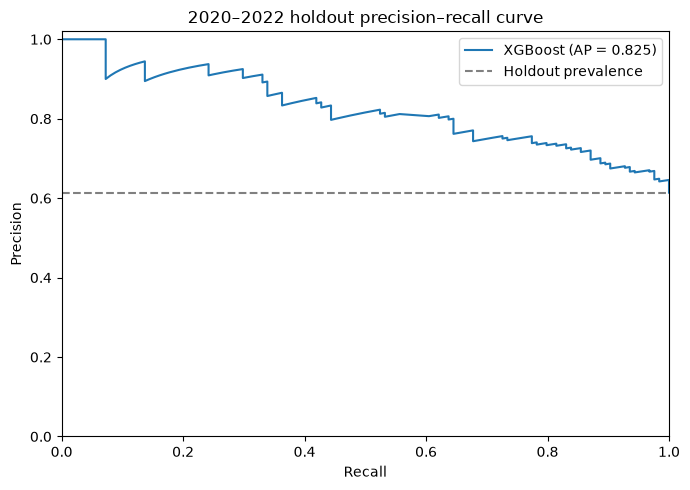

In [5]:
actual = test_predictions[target].astype(int).to_numpy()
probability = test_predictions["draft_probability"].to_numpy()
precision_values, recall_values, _ = precision_recall_curve(actual, probability)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(
    recall_values,
    precision_values,
    label=f"XGBoost (AP = {metrics.loc['test', 'average_precision']:.3f})",
)
ax.axhline(actual.mean(), linestyle="--", color="gray", label="Holdout prevalence")
ax.set(
    title="2020–2022 holdout precision–recall curve",
    xlabel="Recall",
    ylabel="Precision",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
ax.legend()
plt.tight_layout()
plt.show()

## What the fitted model relied on

XGBoost importance is descriptive rather than causal. Correlated raw and engineered predictors can divide importance between themselves.

In [6]:
importance = feature_importance(model)
if importance is not None:
    print("Top transformed features:")
    display(importance.head(12).reset_index(drop=True))

rank_columns = list(dict.fromkeys(config.get("id_columns", []) + [
    year_column, target, "draft_probability", "predicted_drafted",
    "probability_rank_within_year",
]))
top_ranked = (
    test_predictions.sort_values([year_column, "probability_rank_within_year"])
    .groupby(year_column, sort=True)
    .head(5)
)
print("Five highest-ranked Combine participants per holdout year:")
display(top_ranked[rank_columns])

Top transformed features:


,feature,importance
0,numeric__college_age_adjusted_stocks,0.027486
1,numeric__college_age_adjusted_scoring,0.023829
2,numeric__college_career_playmaking_margin_per_40,0.022066
3,numeric__college_last_production_index,0.021792
4,numeric__combine_drill_standing_vertical_leap,0.021048
5,numeric__college_career_three_pct,0.021008
6,numeric__college_last_stocks_per_40_advanced,0.019983
7,numeric__combine_drill_max_vertical_leap,0.019965
8,numeric__college_last_minutes,0.019739
9,numeric__college_career_stocks_per_40_advanced,0.019141


Five highest-ranked Combine participants per holdout year:


,nba_player_id,draft_year,drafted,draft_probability,predicted_drafted,probability_rank_within_year
372,1630192,2020,1,0.762358,1,1
368,1630188,2020,1,0.758714,1,2
371,1630191,2020,1,0.730755,1,3
287,1629604,2020,1,0.711336,1,4
295,1629617,2020,1,0.703300,1,5
470,1630596,2021,1,0.793709,1,1
469,1630595,2021,1,0.765401,1,2
386,1630215,2021,1,0.749954,1,3
425,1630546,2021,0,0.710262,1,4
422,1630543,2021,1,0.697558,1,5


### How to interpret this model

This is a post-Combine model for the complete Combine-participant cohort, not every NCAA player. The annual binary rule selects a fixed fraction within each year, so it should not be used on isolated prospects or an incomplete yearly batch. Average precision and ROC-AUC are the clean holdout ranking claims. The operating rule was repaired after the original holdout run exposed a threshold/refit scale mismatch, so its precision, recall, F1, and balanced accuracy still need confirmation on a future cohort. Feature importance is not causal, and the 2020–2022 test labels should not be used for more tuning.